<a href="https://colab.research.google.com/github/osoliman/DSC110/blob/main/Prediction/DSC110_Prediction_Model_Evaluation_Explanation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model Evaluation and Explanation**

Model Evaluation

Evaluation of Classification models

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [18]:
X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')

#to prevent warning, converting the y from df to 1d series
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

In [19]:
#Build the model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
#Predict the test set
# predict_proba gives probability for each class
# [:, 1] = probability of being the positive class (e.g. diabetic)
y_prob = rf.predict_proba(X_test)[:, 1]

In [9]:
y_prob

array([0.11, 0.  , 0.  , ..., 0.08, 0.42, 0.08])

In [10]:
# Default: classify as positive if prob >= 0.5
y_pred = (y_prob >= 0.5).astype(int)

In [11]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

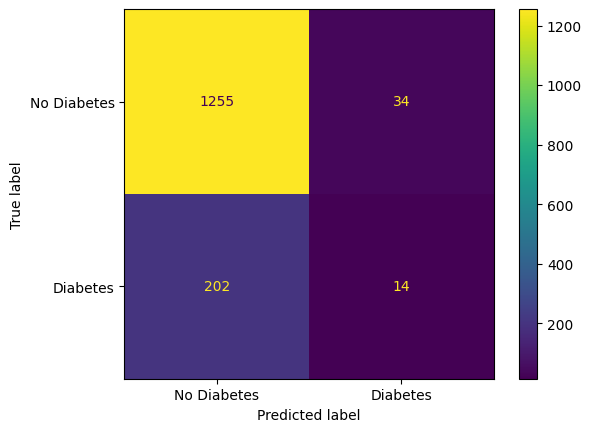

In [21]:
y_pred = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

Changing the threshold

In [22]:
# Changing threshold to 0.3: classify as positive if prob >= 0.3
y_pred_03 = (y_prob >= 0.3).astype(int)

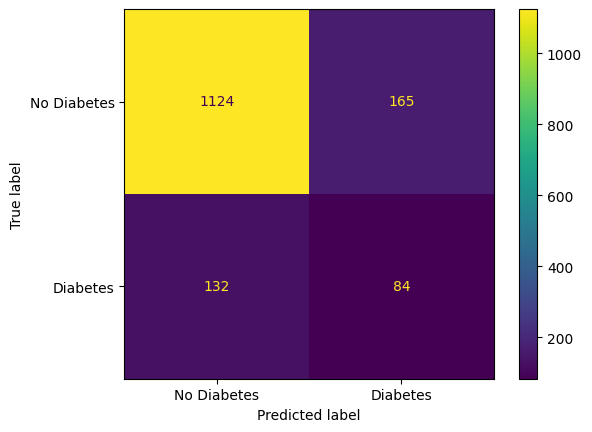

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_03, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

In [24]:
# Changing threshold to 0.7: classify as positive if prob >= 0.7
y_pred_07 = (y_prob >= 0.7).astype(int)

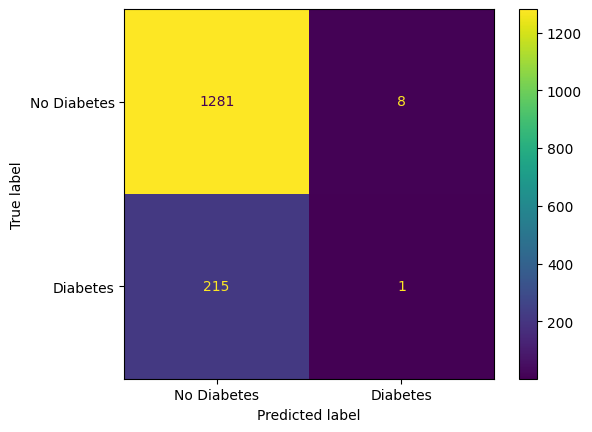

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_07, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

In [26]:
# Changing threshold to 0.2: classify as positive if prob >= 0.2
y_pred_02 = (y_prob >= 0.2).astype(int)

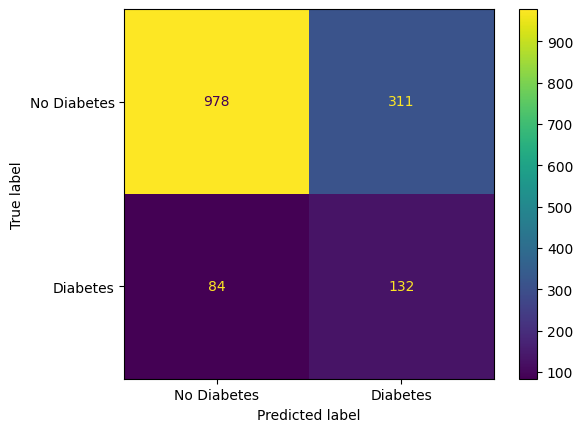

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_02, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

Sensitivity

In [29]:
from sklearn.metrics import recall_score
sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(sensitivity)

0.06481481481481481


In [31]:
sensitivity_02 = recall_score(y_test, y_pred_02, pos_label=1)
print(sensitivity_02)

0.6111111111111112


In [32]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred, target_names=["Not Diabetic", "Diabetic"]))
print(f"AUC: {roc_auc_score(y_test, y_prob):.2f}")

              precision    recall  f1-score   support

Not Diabetic       0.86      0.97      0.91      1289
    Diabetic       0.29      0.06      0.11       216

    accuracy                           0.84      1505
   macro avg       0.58      0.52      0.51      1505
weighted avg       0.78      0.84      0.80      1505

AUC: 0.75
